Скачиваем все необходимые библиотеки

In [78]:
%pip install pandas
%pip install torch
%pip install sklearn
%pip install pymorphy3
%pip install nltk


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Импортируем и сокращаем названия для использования

In [79]:
import pandas as pd
import torch as th
import torch.nn as nn
import torch.optim as optim
import sklearn as sk
from sklearn.linear_model import LogisticRegression
import pymorphy3
import re

Переменной dt с помощью pandas даем json файл с нашими данными (прописываем lines=True, для того что бы он читал документ построчно, иначе просто сломается)

In [80]:
dt = pd.read_json("test.jsonl", lines=True)

Выведем наш файл для проверки,видно,что у нас есть всего 4 колонки, идеальный баланс классов (1:1:1),а так же текст,который на данный момент очень грязный, теперь нам нужно его почистить

In [81]:
print (dt.info())
print(dt['label'].value_counts())
print(dt['text'].iloc[0]) 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          1500 non-null   int64 
 1   text        1500 non-null   object
 2   label       1500 non-null   int64 
 3   label_text  1500 non-null   object
dtypes: int64(2), object(2)
memory usage: 47.0+ KB
None
label
1    500
0    500
2    500
Name: count, dtype: int64
Шла на сеанс, не ожидая ничего сверхъестественного ни от Джессики Симпсон ни от самого фильма. И надо сказать, ушла из кинотеатра с приятным удивлением в душе. Надо же, как ей идут роли деревенских простушек в самом лучшем смысле этих слов. Сначала в «Придурках из Хаззарда», а теперь тут Джесси просто блеснула своим врожденным обаянием.

Пусть она далеко не самая хорошая актриса, но фильм получился лучше, чем я ожидала. Смотреть было приятно, смешно и весело. Мы с друзьями отправились домой в превосходном расположении духа, а мне даж

из pymorhy3 достаем класс который может рабоать с русским языком,затем созадем функцию в которой будем чистить язык,переводим все в нижний регистр,затем с помощью re.sub(найти и заменить) мы ищем все,что не буквы и не пробел (r'[^а-яА-ЯёЁ ]) заменяя это все на пустоту, затем разбиение на токены (в этом случае по словам через split), созадем список куда будем кидать уже готовые слова, запускаем цикл который проходит по словам нормализует их и кидает в наш список, (normal_form = morph.parse(word)[0].normal_form), по кускам (morph.parse(word)) разбивает слово на список вариантов отсортированных по наиболее вероятный, нам логично нужен самый главный по этому из этого списка мы достаем первый ([0]), normal_form приводит наше слово в его "начальную" форму, затем уже готовое слово кидаем в наш список,но наши модельки со списками работать не будут,нам нужны строчки поэтому мы возвращаем в конце функции список который склеивает все в ожну строку и разделяет пробелами, в конце можем глянуть,что все работает, выводим чистый текст из нашей таблицы и выводим тот же текст,который питон проганяет сначала через нашу функцию очистки, видно,что все отлично сработало,а значит можно применить это ко всем нашим данным

In [82]:
morph = pymorphy3.MorphAnalyzer()
def lemmatize_text(text):
    text = text.lower()
    text = re.sub(r'[^а-яА-ЯёЁ ]', '', text)
    words = text.split()


    clean_words = []
    for word in words:
        normal_form = morph.parse(word)[0].normal_form
        clean_words.append(normal_form)
    return ' '.join(clean_words)


print(dt['text'].iloc[0]) 
print(lemmatize_text(dt['text'].iloc[0]))



dt['cleaned_text'] = dt['text'].apply(lemmatize_text)

Шла на сеанс, не ожидая ничего сверхъестественного ни от Джессики Симпсон ни от самого фильма. И надо сказать, ушла из кинотеатра с приятным удивлением в душе. Надо же, как ей идут роли деревенских простушек в самом лучшем смысле этих слов. Сначала в «Придурках из Хаззарда», а теперь тут Джесси просто блеснула своим врожденным обаянием.

Пусть она далеко не самая хорошая актриса, но фильм получился лучше, чем я ожидала. Смотреть было приятно, смешно и весело. Мы с друзьями отправились домой в превосходном расположении духа, а мне даже за рулем по дороге вспоминалась та потешная сцена, где она с велосипедом вместе повалилась в строительную яму.

Такое кино ни к чему не обязывает и в этом его прелесть. Оно не испортит никому настроения, разве что серьезным дядям из киноакадемии, которые раздают Оскары. Но ведь это не мы с вами :)

А то, что «Блондинка с амбициями» лучше «Блондинки в шоколаде» можна сказать даже не смотрев ни то ни другое. Просто в актерском составе первого фильма нету Пе

импортируем из sklearn TF-IDF затем даем ее переменной с параметрами (min_df=3) означает в каком минимуме документах должно быть слово (в нашем случае как минимум в 3), а (max_df) - говорит модели игнорировать слова выше процентного значения обозначающие нахождения во всех документах, (в нашем случае если больше чем в 90% то игнорируем), затем мы обучаем модельку и получаем матрицу размерностью 1500: "количество слов которые получила модель", !!Разбил на н-граммы,а не слова,матрица получилась больше,но и score увеличился с 0,59 до 0,62

Удалим стоп-слова добавим nltk
(упало до 0,6)

In [83]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words_ru = stopwords.words('russian')


tfidf = TfidfVectorizer(min_df=3, max_df=0.9, ngram_range=(1, 2), stop_words=stop_words_ru)

X = tfidf.fit_transform(dt['cleaned_text'])


print(X.shape)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


(1500, 18064)


теперь мы можем приступить к обучению нашей модели, сначала нужно разбить данные, импортируем из sklearn для разбиения, выдаем у метку лейбл которую и нужно будет предсказать, затем разбиваем трейн и тест в пропорции 80 на 20,выводим и видим,что все отлично

In [84]:
from sklearn.model_selection import train_test_split


y = dt['label'] 


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=19)


print("Всего данных:", X.shape)
print("Учебник:", X_train.shape)
print("Экзамен:", X_test.shape)

Всего данных: (1500, 18064)
Учебник: (1200, 18064)
Экзамен: (300, 18064)


Для классификации можно выбрать логрег как идеальную простую модель,импортируем ее и передаем в переменную,обучаем на наших трейнах и выводим результат
1) получилось 0,59 (возможно стоит разбить на н-граммы)
2) после разбиения получилось получше 0,62 (нужно посмотреть на чем спотыкается и что не так со словами)
3) удалил стоп-слова,но почему то стало хуже 0,60 (нужно построить матрицу ошибок)

In [85]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(random_state=19)


print("Начинаю обучение...")
model.fit(X_train, y_train)
print("Обучение завершено!")


accuracy = model.score(X_test, y_test)
print(f"Точность модели на тесте: {accuracy:.2f}")

Начинаю обучение...
Обучение завершено!
Точность модели на тесте: 0.60


Нужно посмотреть какие слова модель вообще воспринимает за положительные,а какие за негативные, сначала мы вытаскиваем из нашего TF-IDF список слов которые в нем есть, затем счиатаем коээфиценты наших слов, отнимаю у позитивных негативные, затем создаем таблицу, в первую колонку слово,во вторую его вес (чем больше вес тем позитивнее слово,чем меньше тем негативниее, посередине нейтральные слова), потом сортируем наши слова (ascending=False) по убыванию,то есть сверху самые лучшие, (ascending=True) сверху самые худшие веса, затем просто выводим это

Видно,что есть нормальные слова которые подходят,но есть стоп слова которые мешают и по сути не несут смысловой нагрузки по типу (он,ты,быть,на,бы и тд)


после удаления стоп-слов видно,что смысловая нагрузка слов стала больше,но модель все равно показывет себя чуть хуже


In [86]:
feature_names = tfidf.get_feature_names_out()


coefficients = model.coef_[2] - model.coef_[0]


words_df = pd.DataFrame({'слово': feature_names, 'вес': coefficients})


top_positive = words_df.sort_values(by='вес', ascending=False).head(15)
top_negative = words_df.sort_values(by='вес', ascending=True).head(15)

print("Слова позитива")
print(top_positive)

print("Слова негатива")
print(top_negative)

Слова позитива
                   слово       вес
3949               жизнь  2.430987
17033            человек  2.185823
5191              каждый  1.851215
9530               очень  1.779549
7770           настоящий  1.475165
986         великолепный  1.456247
11104          потрясать  1.440631
7003                 мир  1.432250
9355            отличный  1.404999
13093               свой  1.403328
5117             история  1.360187
312            атмосфера  1.357665
6616              любовь  1.259333
9595   очень понравиться  1.182571
7376          мультфильм  1.173206
Слова негатива
            слово       вес
10142      плохой -2.005615
8402      никакой -1.923444
1566       вообще -1.896089
15354       тупой -1.715231
13904     снимать -1.433610
17415       шутка -1.378145
12842  российский -1.375169
14087   создатель -1.360458
9752      пародия -1.327265
3129       деньга -1.296187
2569       глупый -1.288683
5286        както -1.260598
7556     название -1.248157
14807    сценарий 

Создадим матрицу ошибок (на чем модель ошибается больше всего), импортируем, y_pred по сути ответы нашей модели по той части которую мы ей еще не показывали, затем матрицу с ответами моделями и правильными ответами, создаем холст, теперь подключаем seaborn для рисования, (сonf_matrix)-сама матрица, (annot=True)-цифры в квадратах, (cmap='Reds')-просто цвет любой на выбор, xticklabels и  yticklabels это просто наши оси, затем подписываем оси и выводим саму таблицу

видно,что модель в основном ошибается на нейтральных словах и ей сложнее всего маркировать именно их

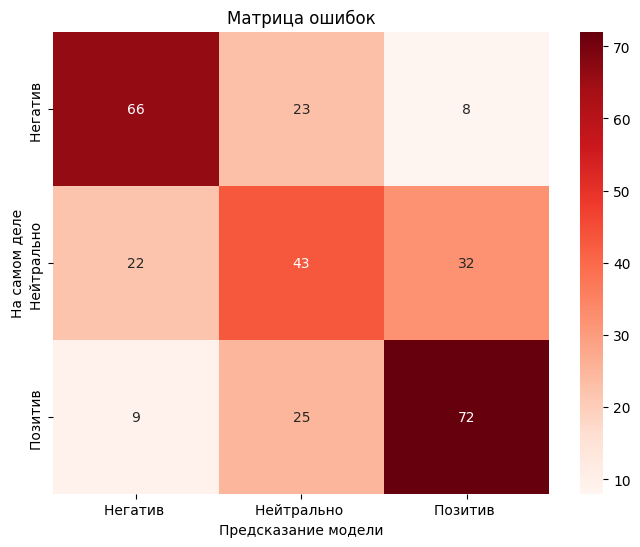

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


y_pred = model.predict(X_test)


conf_matrix = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))


sns.heatmap(conf_matrix, annot=True, cmap='Reds',
            xticklabels=['Негатив ', 'Нейтрально ', 'Позитив '],
            yticklabels=['Негатив ', 'Нейтрально ', 'Позитив '])

plt.xlabel('Предсказание модели')
plt.ylabel('На самом деле')
plt.title('Матрица ошибок')
plt.show()